# Balanced Random Forest — Plantilla reutilizable

Pipeline genérico para entrenar un `BalancedRandomForestClassifier` sobre **cualquier** tabla con clasificación:

1. Grid search de hiperparámetros con `StratifiedKFold`.
2. Cross-validation repetida (`StratifiedShuffleSplit`) que guarda **feature importance por fold**.
3. Matriz de confusión promedio ± std, importancia de features promedio ± std.
4. Modelo final entrenado y persistido con `joblib`.
5. Predicción sobre todo el dataset y CSV con probabilidades por clase.

**Para usarlo en un problema nuevo, edita únicamente la celda `CONFIG`** (ruta de datos, columna target, lista de features). Soporta clasificación binaria y multiclase.

## 0. EJEMPLO RÁPIDO (200 filas reales del paper)

Usa el subsample pre-generado `example_data/brf_sample_200.csv` (200 filas, clases O/B/A, 7 features fotométricas + paralaje).

Ejecuta esta celda y luego corre el notebook completo — un grid search reducido sobre 200 filas toma ~30 s.


In [1]:
# --- Ejemplo: carga subsample pre-generado (200 filas, O/B/A) ---
from pathlib import Path

_features_demo = ['phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag',
                  'j_m', 'h_m', 'ks_m', 'parallax']
example_csv = Path(__file__).parent / 'example_data' / 'brf_sample_200.csv' \
              if '__file__' in dir() \
              else Path('example_data/brf_sample_200.csv')

# Overrides del CONFIG: grid reducido + sin Ray (rápido)
EXAMPLE_CONFIG_OVERRIDES = {
    'data_path':            str(example_csv),
    'target_col':           'spclass',
    'feature_cols':         _features_demo,
    'output_dir':           'example_brf_results',
    'param_grid':           {'n_estimators':      [100, 200],
                               'max_features':    ['sqrt'],
                               'max_depth':       [10, None],
                               'sampling_strategy': ['all']},
    'gridsearch_cv_splits': 3,
    'cv_n_splits':          5,
    'use_ray':              False,
}
print(f'Usando: {example_csv}')
print('CONFIG override listo. Sigue ejecutando el notebook.')


Usando: example_data/brf_sample_200.csv
CONFIG override listo. Sigue ejecutando el notebook.


**Nota:** la celda `CONFIG` siguiente detecta `EXAMPLE_CONFIG_OVERRIDES` y los aplica automáticamente. Para usar tu propio dataset, no ejecutes la celda de arriba (o reinicia el kernel) y edita `CONFIG` normalmente.

## 1. CONFIG — editar aquí

In [2]:
from pathlib import Path

CONFIG = {
    # --- Datos ---
    'data_path':       'path/to/your_table.csv',  # CSV o parquet
    'target_col':      'label',                   # columna con la clase
    'feature_cols':    None,                      # lista de features; None = todas menos el target
    'bad_values':      [-999, 999],               # valores a tratar como inválidos (NaN siempre se descarta)

    # --- Salida ---
    'output_dir':      'results_run1',            # se crea si no existe

    # --- Grid search ---
    'param_grid': {
        'n_estimators':      [500, 800, 1200],
        'max_features':      ['sqrt', 'log2'],
        'max_depth':         [10, 20, 30, None],
        'sampling_strategy': ['majority', 'not majority', 'all'],
    },
    'gridsearch_cv_splits': 5,

    # --- Cross-validation final ---
    'cv_n_splits':     20,
    'cv_test_size':    0.2,
    'random_state':    42,

    # --- Predicción ---
    # Umbral solo aplica si la clasificación es binaria. None = usar argmax (multiclase) o 0.5 (binaria).
    'binary_threshold': None,

    # --- Paralelismo ---
    'n_jobs':          -1,    # para sklearn (-1 = todos los cores)
    'use_ray':         True,  # paraleliza la CV final con Ray
}

OUT = Path(CONFIG['output_dir'])
OUT.mkdir(parents=True, exist_ok=True)
print(f'Outputs irán a: {OUT.resolve()}')

# Si la sección 0 (ejemplo) se ejecutó, aplica sus overrides automáticamente
try:
    CONFIG.update(EXAMPLE_CONFIG_OVERRIDES)
    print('CONFIG actualizado con EXAMPLE_CONFIG_OVERRIDES')
except NameError:
    pass
OUT = Path(CONFIG['output_dir'])
OUT.mkdir(parents=True, exist_ok=True)


Outputs irán a: /home/nicolas/nico/git/OB-stars/reusable/results_run1
CONFIG actualizado con EXAMPLE_CONFIG_OVERRIDES


## 2. Imports

In [3]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, StratifiedShuffleSplit, train_test_split,
)
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, make_scorer,
)
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.metrics import geometric_mean_score, make_index_balanced_accuracy

## 3. Cargar datos y limpiar

In [4]:
def load_table(path):
    p = Path(path)
    if p.suffix == '.parquet':
        return pd.read_parquet(p)
    return pd.read_csv(p)

def clean_features(df, feature_cols, bad_values):
    bad = list(bad_values) + [-v for v in bad_values if isinstance(v, (int, float))]
    mask_bad = df[feature_cols].isin(bad).any(axis=1)
    mask_nan = df[feature_cols].isna().any(axis=1)
    n_drop = (mask_bad | mask_nan).sum()
    print(f'Filas descartadas por NaN o valores inválidos: {n_drop} / {len(df)}')
    return df.loc[~(mask_bad | mask_nan)].reset_index(drop=True)

df = load_table(CONFIG['data_path'])
print(f'Tabla cargada: {df.shape}')

target = CONFIG['target_col']
features = CONFIG['feature_cols']
if features is None:
    features = [c for c in df.select_dtypes(include='number').columns if c != target]
    print(f'Auto-detectadas {len(features)} features numéricas')

df = df.dropna(subset=[target]).reset_index(drop=True)
df = clean_features(df, features, CONFIG['bad_values'])

X = df[features]
y = df[target]
print('Distribución de clases:')
print(y.value_counts())

Tabla cargada: (200, 8)
Filas descartadas por NaN o valores inválidos: 0 / 200
Distribución de clases:
spclass
B    68
O    67
A    65
Name: count, dtype: int64


## 4. Grid search

Usa la métrica `geometric_mean_score` con `index_balanced_accuracy` — robusta para clases desbalanceadas.

In [5]:
def make_iba_gmean_scorer(alpha=0.1):
    iba = make_index_balanced_accuracy(alpha=alpha, squared=True)(geometric_mean_score)
    return make_scorer(iba, average='weighted')

def run_grid_search(X, y, param_grid, n_splits=5, n_jobs=-1, random_state=42):
    clf = BalancedRandomForestClassifier(replacement=True, random_state=random_state)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    gs = GridSearchCV(clf, param_grid, cv=cv, scoring=make_iba_gmean_scorer(),
                      n_jobs=n_jobs, verbose=1)
    gs.fit(X, y)
    return gs

gs = run_grid_search(
    X, y,
    CONFIG['param_grid'],
    n_splits=CONFIG['gridsearch_cv_splits'],
    n_jobs=CONFIG['n_jobs'],
    random_state=CONFIG['random_state'],
)
best_params = gs.best_params_
print('Mejores hiperparámetros:', best_params)
print(f'Mejor score (IBA-Gmean weighted): {gs.best_score_:.4f}')

pd.DataFrame([best_params]).to_csv(OUT / 'best_params.csv', index=False)
pd.DataFrame(gs.cv_results_).to_csv(OUT / 'gridsearch_full_results.csv', index=False)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Mejores hiperparámetros: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200, 'sampling_strategy': 'all'}
Mejor score (IBA-Gmean weighted): 0.4126


## 5. Cross-validation repetida — guarda feature importance por fold

`StratifiedShuffleSplit` con `n_splits` repeticiones. En cada fold:
- Entrena un modelo nuevo con `best_params`.
- Guarda métricas por clase (precision, recall, F1).
- Guarda matriz de confusión.
- **Guarda feature importance del estimador** y su std entre árboles.

Esto da una distribución de importancias sobre los `n_splits` folds — útil para ver qué features son consistentemente relevantes.

In [6]:
def predict_from_proba(proba, classes, binary_threshold=None):
    if len(classes) == 2 and binary_threshold is not None:
        return (proba[:, 1] >= binary_threshold).astype(classes.dtype)
    return classes[np.argmax(proba, axis=1)]

def fit_one_fold(train_idx, test_idx, fold_id, X, y, best_params, binary_threshold):
    Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
    ytr, yte = y.iloc[train_idx], y.iloc[test_idx]
    params = {**best_params, 'replacement': True}
    clf = BalancedRandomForestClassifier(**params)
    clf.fit(Xtr, ytr)

    proba = clf.predict_proba(Xte)
    y_pred = predict_from_proba(proba, clf.classes_, binary_threshold)

    labels_sorted = np.sort(np.unique(y))
    cm = confusion_matrix(yte, y_pred, labels=labels_sorted)

    prec = precision_score(yte, y_pred, labels=labels_sorted, average=None, zero_division=0)
    rec  = recall_score(yte, y_pred, labels=labels_sorted, average=None, zero_division=0)
    f1   = f1_score(yte, y_pred, labels=labels_sorted, average=None, zero_division=0)

    fi = clf.feature_importances_
    fi_std = np.std([t.feature_importances_ for t in clf.estimators_], axis=0)

    metrics = pd.DataFrame({
        'fold': fold_id, 'class': labels_sorted,
        'precision': prec, 'recall': rec, 'f1': f1,
    })
    importance = pd.DataFrame({
        'fold': fold_id, 'feature': clf.feature_names_in_,
        'importance': fi, 'importance_std_within_fold': fi_std,
    })
    return cm, metrics, importance

def run_cv(X, y, best_params, n_splits, test_size, random_state,
           binary_threshold=None, use_ray=False):
    splitter = StratifiedShuffleSplit(n_splits=n_splits, test_size=test_size,
                                       random_state=random_state)
    if use_ray:
        import ray
        if not ray.is_initialized():
            ray.init(ignore_reinit_error=True)
        remote_fit = ray.remote(fit_one_fold)
        futures = [
            remote_fit.remote(tr, te, i, X, y, best_params, binary_threshold)
            for i, (tr, te) in enumerate(splitter.split(X, y))
        ]
        results = ray.get(futures)
    else:
        results = [
            fit_one_fold(tr, te, i, X, y, best_params, binary_threshold)
            for i, (tr, te) in enumerate(splitter.split(X, y))
        ]

    cms        = np.stack([r[0] for r in results], axis=-1)
    metrics_df = pd.concat([r[1] for r in results], ignore_index=True)
    import_df  = pd.concat([r[2] for r in results], ignore_index=True)
    return cms, metrics_df, import_df

cms, cv_metrics, cv_importance = run_cv(
    X, y, best_params,
    n_splits=CONFIG['cv_n_splits'],
    test_size=CONFIG['cv_test_size'],
    random_state=CONFIG['random_state'],
    binary_threshold=CONFIG['binary_threshold'],
    use_ray=CONFIG['use_ray'],
)

cv_metrics.to_csv(OUT / 'cv_metrics_per_fold.csv', index=False)
cv_importance.to_csv(OUT / 'cv_feature_importance_per_fold.csv', index=False)
print(f'Guardadas métricas y feature importance de {CONFIG["cv_n_splits"]} folds')

Guardadas métricas y feature importance de 5 folds


## 6. Resúmenes — matriz de confusión, métricas y feature importance

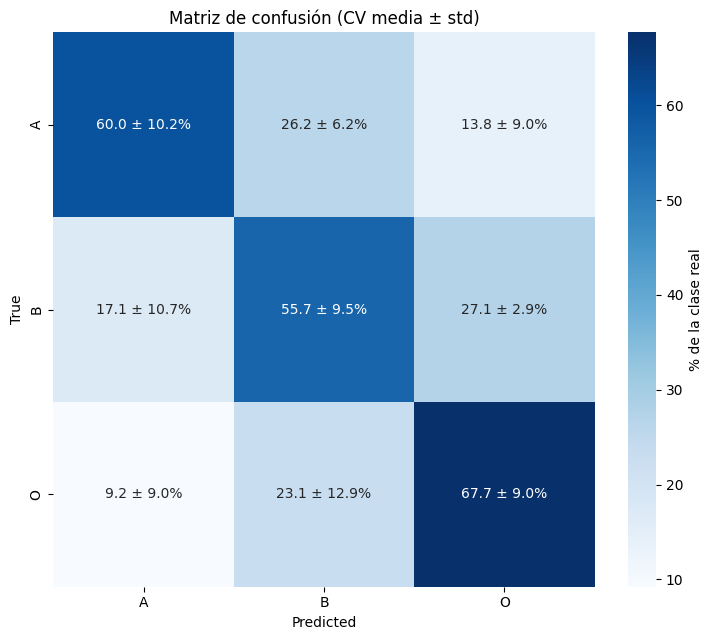

      precision          recall              f1        
           mean     std    mean     std    mean     std
class                                                  
A        0.6983  0.0970  0.6000  0.1141  0.6374  0.0690
B        0.5561  0.1004  0.5571  0.1059  0.5531  0.0917
O        0.6142  0.0587  0.6769  0.1003  0.6408  0.0632


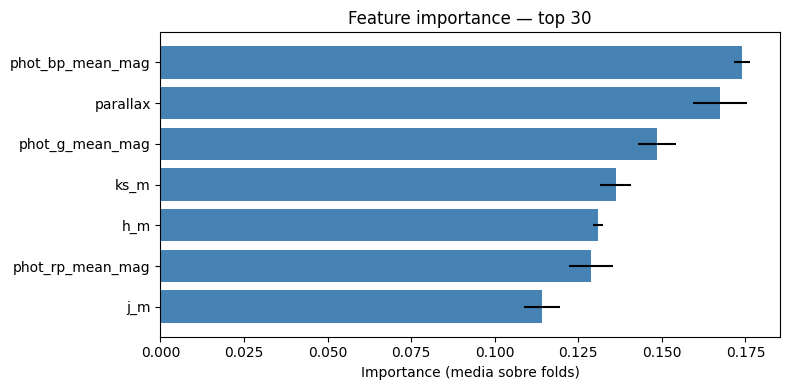

In [7]:
labels_sorted = np.sort(y.unique())

cm_mean = cms.mean(axis=-1)
cm_std  = cms.std(axis=-1)
row_totals = cm_mean.sum(axis=1, keepdims=True)
cm_pct      = cm_mean / row_totals * 100
cm_pct_std  = cm_std  / row_totals * 100

annot = np.array([
    [f'{cm_pct[i,j]:.1f} ± {cm_pct_std[i,j]:.1f}%' for j in range(cm_pct.shape[1])]
    for i in range(cm_pct.shape[0])
])

fig, ax = plt.subplots(figsize=(1.5*len(labels_sorted)+3, 1.5*len(labels_sorted)+2))
sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues',
            xticklabels=labels_sorted, yticklabels=labels_sorted, ax=ax,
            cbar_kws={'label': '% de la clase real'})
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Matriz de confusión (CV media ± std)')
plt.tight_layout()
plt.savefig(OUT / 'confusion_matrix.pdf', bbox_inches='tight')
plt.show()

metrics_summary = (
    cv_metrics.groupby('class')[['precision', 'recall', 'f1']]
    .agg(['mean', 'std']).round(4)
)
metrics_summary.to_csv(OUT / 'cv_metrics_summary.csv')
print(metrics_summary)

fi_summary = (
    cv_importance.groupby('feature')['importance']
    .agg(['mean', 'std']).sort_values('mean', ascending=False)
)
fi_summary.to_csv(OUT / 'cv_feature_importance_summary.csv')

top = fi_summary.head(30)
fig, ax = plt.subplots(figsize=(8, max(4, 0.3*len(top))))
ax.barh(top.index[::-1], top['mean'][::-1], xerr=top['std'][::-1], color='steelblue')
ax.set_xlabel('Importance (media sobre folds)')
ax.set_title('Feature importance — top 30')
plt.tight_layout()
plt.savefig(OUT / 'feature_importance.pdf', bbox_inches='tight')
plt.show()

## 7. Modelo final + predicción sobre todo el dataset

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CONFIG['cv_test_size'],
    random_state=CONFIG['random_state'], stratify=y,
)
final_params = {**best_params, 'replacement': True}
final = BalancedRandomForestClassifier(**final_params)
final.fit(X_train, y_train)

joblib.dump(final, OUT / 'model.joblib')
print(f'Modelo guardado en {OUT / "model.joblib"}')

y_pred_test = final.predict(X_test)
print(classification_report(y_test, y_pred_test, zero_division=0))

proba_all = final.predict_proba(df[features])
df_out = df.copy()
df_out['split'] = 'unused'
df_out.loc[X_train.index, 'split'] = 'train'
df_out.loc[X_test.index,  'split'] = 'test'
for i, cls in enumerate(final.classes_):
    df_out[f'prob_{cls}'] = proba_all[:, i]
df_out['predicted'] = predict_from_proba(proba_all, final.classes_, CONFIG['binary_threshold'])

df_out.to_csv(OUT / 'predictions.csv', index=False)
print(f'Predicciones guardadas en {OUT / "predictions.csv"}')

Modelo guardado en example_brf_results/model.joblib
              precision    recall  f1-score   support

           A       0.80      0.62      0.70        13
           B       0.67      0.71      0.69        14
           O       0.67      0.77      0.71        13

    accuracy                           0.70        40
   macro avg       0.71      0.70      0.70        40
weighted avg       0.71      0.70      0.70        40

Predicciones guardadas en example_brf_results/predictions.csv


## 8. Cleanup

In [9]:
if CONFIG['use_ray']:
    import ray
    if ray.is_initialized():
        ray.shutdown()
print('Listo. Archivos en', OUT.resolve())

Listo. Archivos en /home/nicolas/nico/git/OB-stars/reusable/example_brf_results
